In [1]:
from rdkit import Chem
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, ShuffleSplit, GridSearchCV, cross_val_score, cross_validate
import os
import glob
from scipy.stats import norm
import math
import random

In [2]:
T_0 = pd.read_excel('NLRP3y.xlsx')
T=np.array(T_0)
from sklearn import preprocessing  
print(T)  
print(len(T))


[[10.15]
 [ 9.82]
 [ 9.64]
 ...
 [ 4.13]
 [ 4.09]
 [ 4.08]]
1638


In [3]:
X=pd.read_excel('NLRP3x.xlsx')
X=np.array(X)
from sklearn import preprocessing  
print(X)
print(len(X[0]))
print(len(X))

[[ 1  0  0 ...  0  0 16]
 [ 1  0  1 ...  0  0 15]
 [ 1  0  0 ...  0  0 14]
 ...
 [ 1  0  0 ...  0  0 20]
 [ 1  0  1 ...  0  0 25]
 [ 1  0  0 ...  0  0 18]]
1638
1638


In [4]:
#交叉验证部分

In [43]:
from sklearn.model_selection import train_test_split
X_train,  X_test,  T_train,  T_test  =  train_test_split(X,T,test_size=0.200,random_state=60)

In [196]:
test_y = T_test
test_x = X_test

In [197]:
cv_x = X_train
cv_y = T_train

In [198]:
import lightgbm as lgb  
from sklearn.model_selection import KFold  
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error  
import numpy as np  
    
  
cv_scores = []  
train_r2_scores = []  
train_mae_scores = []  
train_rmse_scores = []  
test_scores = []  
MAE_scores = []  
RMSE_scores = []  
  
kf = KFold(n_splits=10, shuffle=True, random_state=725)  
for train_ix, valid_ix in kf.split(cv_x):  
    train_x = cv_x[train_ix]  
    valid_x = cv_x[valid_ix]  
    train_y = cv_y[train_ix]  
    valid_y = cv_y[valid_ix]  
      
    clf = XGBRegressor(
        n_estimators=300,       # 增加树的数量，通常100-1000之间
    learning_rate=0.1,     # 降低学习率，通常0.01-0.3之间
    max_depth=5,            # 限制树的最大深度，通常3-10之间
    min_child_weight=1,     # 控制叶子节点最小样本权重和
    subsample=0.9,          # 样本采样比例
    colsample_bytree=0.8,   # 特征采样比例
    n_jobs=1,              # 使用所有CPU核心
    random_state=42,         # 随机种子
    reg = 0.1,       # L2正则化
    alpha = 0.4,
)

    clf.fit(train_x, train_y)  
      
    # 训练集预测  
    train_predictions = clf.predict(train_x)  
      
    # 计算训练集的R2, MAE, RMSE  
    train_r2 = r2_score(train_y, train_predictions)  
    train_mae = mean_absolute_error(train_y, train_predictions)  
    train_rmse = np.sqrt(mean_squared_error(train_y, train_predictions))  
      
    # 存储训练集的指标  
    train_r2_scores.append(train_r2)  
    train_mae_scores.append(train_mae)  
    train_rmse_scores.append(train_rmse)  
      
    # 验证集预测  
    val_results = clf.predict(valid_x)  
      
    # 计算验证集的R2  
    valid_score = r2_score(valid_y, val_results)  
    cv_scores.append(valid_score)  
      
    # 假设 test_x 和 test_y 已经被定义，进行测试集预测  
    test_results = clf.predict(test_x)  
    test_score = r2_score(test_y, test_results)  
    test_scores.append(test_score)  
      
    # 计算测试集的MAE和RMSE  
    mae_score = mean_absolute_error(test_y, test_results)  
    MAE_scores.append(mae_score)  
      
    rmse_score = np.sqrt(mean_squared_error(test_y, test_results))  
    RMSE_scores.append(rmse_score)  
  
# 输出训练集的结果  
print('Training R2 scores: mean = {:.3f}, std = {:.3f}'.format(np.mean(train_r2_scores), np.std(train_r2_scores)))  
print('Training MAE scores: mean = {:.3f}, std = {:.3f}'.format(np.mean(train_mae_scores), np.std(train_mae_scores)))  
print('Training RMSE scores: mean = {:.3f}, std = {:.3f}'.format(np.mean(train_rmse_scores), np.std(train_rmse_scores)))  
  
# 输出验证集的结果  
print('Cross-validation R2 scores: mean = {:.3f}, std = {:.3f}'.format(np.mean(cv_scores), np.std(cv_scores)))  
  
# 输出测试集的结果  
print('Test R2 scores: mean = {:.3f}, std = {:.3f}'.format(np.mean(test_scores), np.std(test_scores)))  
print('Test MAE scores: mean = {:.3f}, std = {:.3f}'.format(np.mean(MAE_scores), np.std(MAE_scores)))  
print('Test RMSE scores: mean = {:.3f}, std = {:.3f}'.format(np.mean(RMSE_scores), np.std(RMSE_scores)))

/home/rdkit/anaconda3/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [17:50:02] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "reg" } are not used.

  warnings.warn(smsg, UserWarning)
/home/rdkit/anaconda3/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [17:50:03] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "reg" } are not used.

  warnings.warn(smsg, UserWarning)
/home/rdkit/anaconda3/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [17:50:03] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "reg" } are not used.

  warnings.warn(smsg, UserWarning)
/home/rdkit/anaconda3/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [17:50:04] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "reg" } are not used.

  warnings.warn(smsg, UserWarning)
/home/rdkit/anaconda3/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [17:50:04] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "reg" } are not us

Training R2 scores: mean = 0.927, std = 0.002
Training MAE scores: mean = 0.200, std = 0.003
Training RMSE scores: mean = 0.287, std = 0.004
Cross-validation R2 scores: mean = 0.624, std = 0.069
Test R2 scores: mean = 0.716, std = 0.008
Test MAE scores: mean = 0.414, std = 0.008
Test RMSE scores: mean = 0.564, std = 0.008


In [199]:
print('test: {:.3f}+-{:.3f}'.format(np.array(test_scores).mean(), np.array(test_scores).std()))
print('test: {:.3f}+-{:.3f}'.format(np.array(MAE_scores).mean(), np.array(MAE_scores).std()))
print('test: {:.3f}+-{:.3f}'.format(np.array(RMSE_scores).mean(), np.array(RMSE_scores).std()))

test: 0.716+-0.008
test: 0.414+-0.008
test: 0.564+-0.008


In [4]:
from sklearn.model_selection import train_test_split
X_train,  X_test,  T_train,  T_test  =  train_test_split(X,T,test_size=0.20,random_state=60)

In [5]:
from xgboost import XGBRegressor

clf = XGBRegressor(
    n_estimators=300,       # 增加树的数量，通常100-1000之间
    learning_rate=0.1,     # 降低学习率，通常0.01-0.3之间
    max_depth=5,            # 限制树的最大深度，通常3-10之间
    min_child_weight=1,     # 控制叶子节点最小样本权重和
    subsample=0.9,          # 样本采样比例
    colsample_bytree=0.8,   # 特征采样比例
    n_jobs=1,              # 使用所有CPU核心
    random_state=42,         # 随机种子
    reg = 0.1,       # L2正则化
    alpha = 0.4,     # L1正则化
)
clf.fit(X_train, T_train)

/home/rdkit/anaconda3/lib/python3.9/site-packages/xgboost/core.py:160: UserWarning: [04:39:02] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "reg" } are not used.

  warnings.warn(smsg, UserWarning)


XGBRegressor(alpha=0.4, base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=1,
             num_parallel_tree=None, ...)

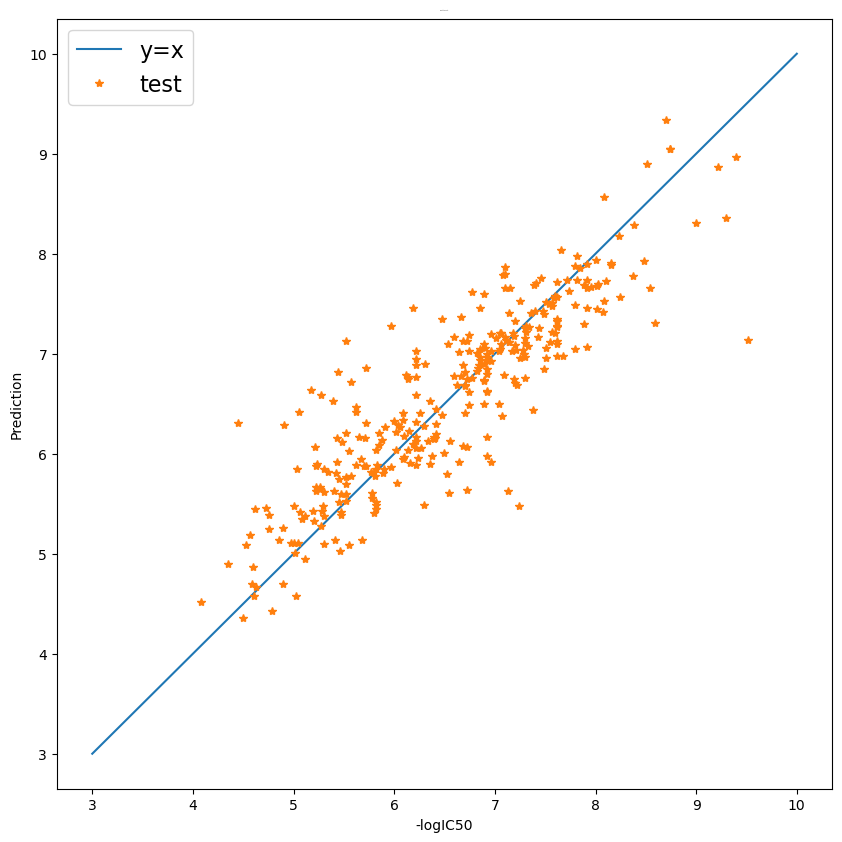

In [6]:
import matplotlib.pyplot as plt

y_true_test=T_test
y_pred_test=clf.predict(X_test)
legend=["y=x","test"]
fig = plt.figure(figsize=(10,10))
plt.plot(range(3,11), range(3,11),"-")
plt.plot(y_true_test, y_pred_test,"*")
plt.xlabel("-logIC50", fontsize=10)
plt.ylabel('Prediction', fontsize=10)
plt.legend(legend,fontsize=16)
plt.title('Scatter Plot', fontsize=1)
plt.show()

In [7]:
from sklearn.metrics import r2_score
print ("测试集 r^2 score",r2_score(T_test,y_pred_test))

测试集 r^2 score 0.7654682924184423


In [8]:
from sklearn.metrics import mean_absolute_error
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
y_true=T_test
y_pred=clf.predict(X_test)
mean_absolute_error(y_true, y_pred)
#np.sqrt(mean_squared_error(y_true,y_pred))

0.371975211166754

In [9]:
np.sqrt(mean_squared_error(y_true,y_pred))

0.5118388157731952

In [27]:
y_pred_test=clf.predict(X_test)
df=pd.DataFrame(y_pred_test)
df.to_csv("./IC50/resulttestPreLGBG1.csv",index=False,header=False)
y_true=T_test
df=pd.DataFrame(y_true)
df.to_csv("./IC50/resulttestTrueLGBG1.csv",index=False,header=False)

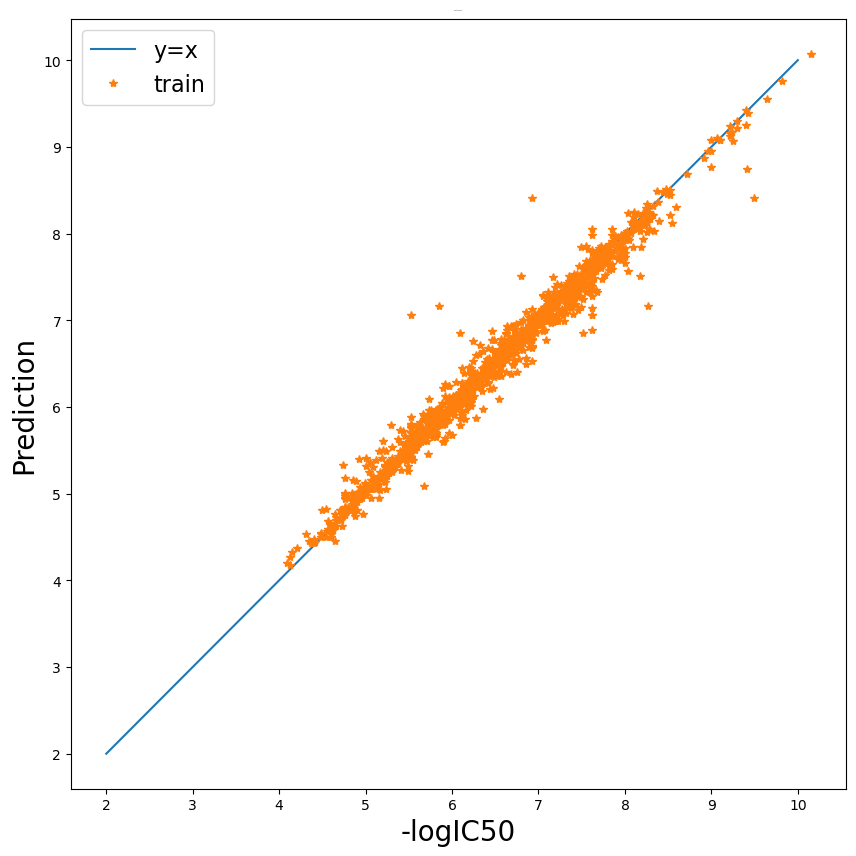

In [10]:
#查看散点图
import matplotlib.pyplot as plt
y_true_train=T_train
y_pred_train=clf.predict(X_train)

legend=["y=x","train"]
fig = plt.figure(figsize=(10,10))
plt.plot(range(2,11), range(2,11),"-")
plt.plot(y_true_train, y_pred_train,"*")
plt.xlabel("-logIC50", fontsize=20)
plt.ylabel('Prediction', fontsize=20)
plt.legend(legend,fontsize=16)
plt.title('Scatter Plot', fontsize=1)
plt.show()

In [11]:
from sklearn.metrics import r2_score
print ("训练集 r^2 score",r2_score(T_train,y_pred_train))

训练集 r^2 score 0.9775405919574989


In [12]:
from sklearn.metrics import mean_absolute_error
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
y_true=T_train
y_pred=clf.predict(X_train)
mean_absolute_error(y_true, y_pred)
#np.sqrt(mean_squared_error(y_true,y_pred))

0.09643587249289944

In [13]:
np.sqrt(mean_squared_error(y_true,y_pred))

0.15935205245040285

In [14]:
print("整体",clf.score(X,T))

整体 0.9354836198534504


In [33]:
y_pred_train=clf.predict(X_train)
df=pd.DataFrame(y_pred_train)
df.to_csv("./IC50/resulttrainPreLGBG1.csv",index=False,header=False)
y_true=T_train
df=pd.DataFrame(y_true)
df.to_csv("./IC50/resulttrainTrueLGBG1.csv",index=False,header=False)

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score
clf = RandomForestRegressor (
bootstrap=True, criterion='mse', max_depth=None,
max_features='auto', max_leaf_nodes=None,
min_impurity_decrease=0.0, min_samples_leaf=1, min_samples_split=2,
min_weight_fraction_leaf=0.0, n_estimators=300, n_jobs=1,
oob_score=False, random_state=None, verbose=0, warm_start=False)
clf.fit (X_train,T_train)
train=clf.score(X_train,T_train)
test=clf.score(X_test, T_test)


/tmp/ipykernel_38541/3157236438.py:9: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  clf.fit (X_train,T_train)
/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_forest.py:396: FutureWarning: Criterion 'mse' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='squared_error'` which is equivalent.
  warn(


In [169]:
from sklearn.svm import SVR
clf = SVR(C=10.0, cache_size=200, coef0=0.0, degree=3, epsilon=0.2, gamma=0.002,
    kernel='rbf', max_iter=-1, shrinking=True, tol=0.001, verbose=False)
clf.fit (X_train,T_train)

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR(C=10.0, epsilon=0.2, gamma=0.002)

In [88]:
from sklearn.cross_decomposition import PLSRegression
clf = PLSRegression(n_components=10)
clf.fit(X_train, T_train)  # 训练模型

PLSRegression(n_components=10)

In [127]:
from sklearn import linear_model
clf = linear_model.Lasso(max_iter=200, random_state=0, alpha=0.01)  # 设置正则化强度
clf.fit(X_train, T_train)  # 参数拟合
#print(regressor.coef_)  # 系数
#print(regressor.intercept_)  # 常量系数
#print(regressor.score(X, T))  # R^2，拟合优度
#print(regressor.get_params())  # 获取参数信息
#print(regressor.set_params(fit_intercept=False))  # 重
#print(regressor.predict(X))

/home/rdkit/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:647: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.442e-01, tolerance: 1.481e-01
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=0.01, max_iter=200, random_state=0)

In [164]:
from sklearn.neighbors import KNeighborsRegressor
clf = KNeighborsRegressor (n_neighbors=3)
clf.fit (X_train,T_train)
train=clf.score(X_train,T_train)
test=clf.score(X_test, T_test)